# File này xử lý việc Phân tích và Tiền xử lý Dữ liệu, các file khác dùng file dataset.csv để dùng data đã được xử lý


## 1. Mô tả dữ liệu

In [2]:
import pandas as pd
import numpy as np

# 1. MÔ TẢ DỮ LIỆU
# Đọc file Excel
df = pd.read_excel('data/Dry_Bean_Dataset.xlsx')

print(f"Kích thước dữ liệu: {df.shape}")
print("\nThông tin các cột:")
print(df.info())
# Biến mục tiêu là 'Class' (loại hạt đậu)

Kích thước dữ liệu: (13611, 17)

Thông tin các cột:
<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            

## 2. Phân tích khám phá (EDA):

### 1. Thống kê mô tả: mean, std, min, max, tứ phân vị.

In [3]:
# Thống kê mô tả các biến số
print(df.describe())


                Area     Perimeter  MajorAxisLength  MinorAxisLength  \
count   13611.000000  13611.000000     13611.000000     13611.000000   
mean    53048.284549    855.283459       320.141867       202.270714   
std     29324.095717    214.289696        85.694186        44.970091   
min     20420.000000    524.736000       183.601165       122.512653   
25%     36328.000000    703.523500       253.303633       175.848170   
50%     44652.000000    794.941000       296.883367       192.431733   
75%     61332.000000    977.213000       376.495012       217.031741   
max    254616.000000   1985.370000       738.860153       460.198497   

       AspectRation  Eccentricity     ConvexArea  EquivDiameter        Extent  \
count  13611.000000  13611.000000   13611.000000   13611.000000  13611.000000   
mean       1.583242      0.750895   53768.200206     253.064220      0.749733   
std        0.246678      0.092002   29774.915817      59.177120      0.049086   
min        1.024868      0.

### 2. Phân bố của biến mục tiêu (histogram, boxplot).

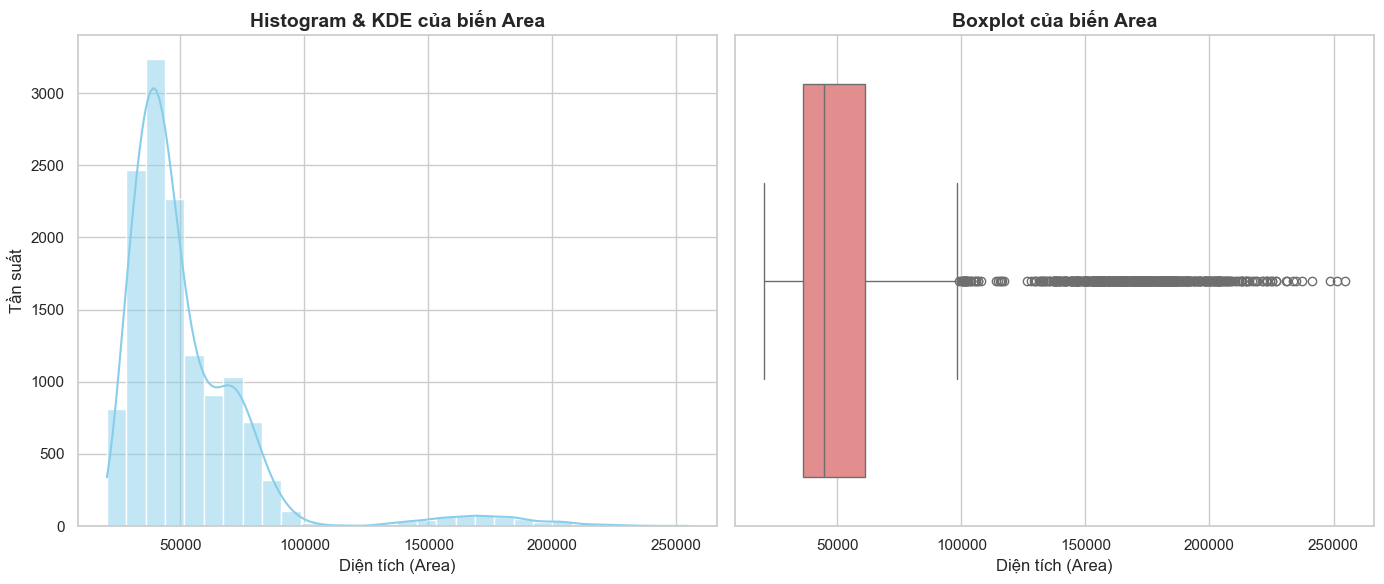

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập phong cách cho đồ thị
sns.set_theme(style="whitegrid")

# Khởi tạo khung hình gồm 1 hàng và 2 cột
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Vẽ Histogram (Biểu đồ tần suất) kèm đường mật độ KDE
sns.histplot(df['Area'], kde=True, ax=axes[0], color='skyblue', bins=30)
axes[0].set_title('Histogram & KDE của biến Area', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diện tích (Area)')
axes[0].set_ylabel('Tần suất')

# 2. Vẽ Boxplot (Biểu đồ hộp) để phát hiện ngoại lai
sns.boxplot(x=df['Area'], ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot của biến Area', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Diện tích (Area)')

# Căn chỉnh bố cục
plt.tight_layout()
plt.show()


Số lượng mẫu mỗi loại đậu:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


C:\Users\LAPTOPBKU.COM\AppData\Local\Temp\ipykernel_30424\3304594859.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='viridis', order=df['Class'].value_counts().index)


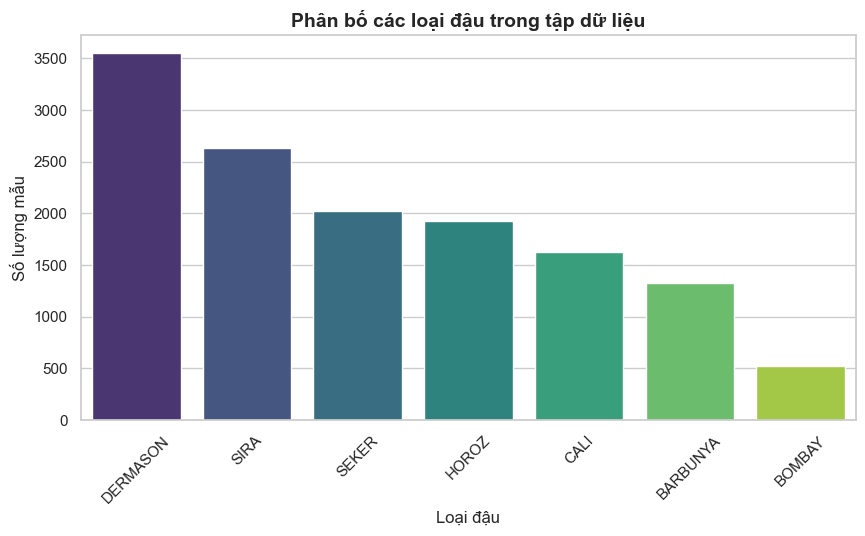


Tỷ lệ phần trăm các lớp:
Class
DERMASON    26.052458
SIRA        19.366689
SEKER       14.892366
HOROZ       14.165014
CALI        11.975608
BARBUNYA     9.712732
BOMBAY       3.835133
Name: proportion, dtype: float64


In [5]:
# Kiểm tra số lượng mẫu của từng loại đậu
print("\nSố lượng mẫu mỗi loại đậu:")
print(df['Class'].value_counts())

# Vẽ biểu đồ cột để trực quan hóa độ cân bằng
plt.figure(figsize=(10, 5))
sns.countplot(x='Class', data=df, palette='viridis', order=df['Class'].value_counts().index)
plt.title('Phân bố các loại đậu trong tập dữ liệu', fontsize=14, fontweight='bold')
plt.xlabel('Loại đậu')
plt.ylabel('Số lượng mẫu')
plt.xticks(rotation=45)
plt.show()

# Tính tỷ lệ phần trăm
print("\nTỷ lệ phần trăm các lớp:")
print(df['Class'].value_counts(normalize=True) * 100)

### 3. Ma trận tương quan

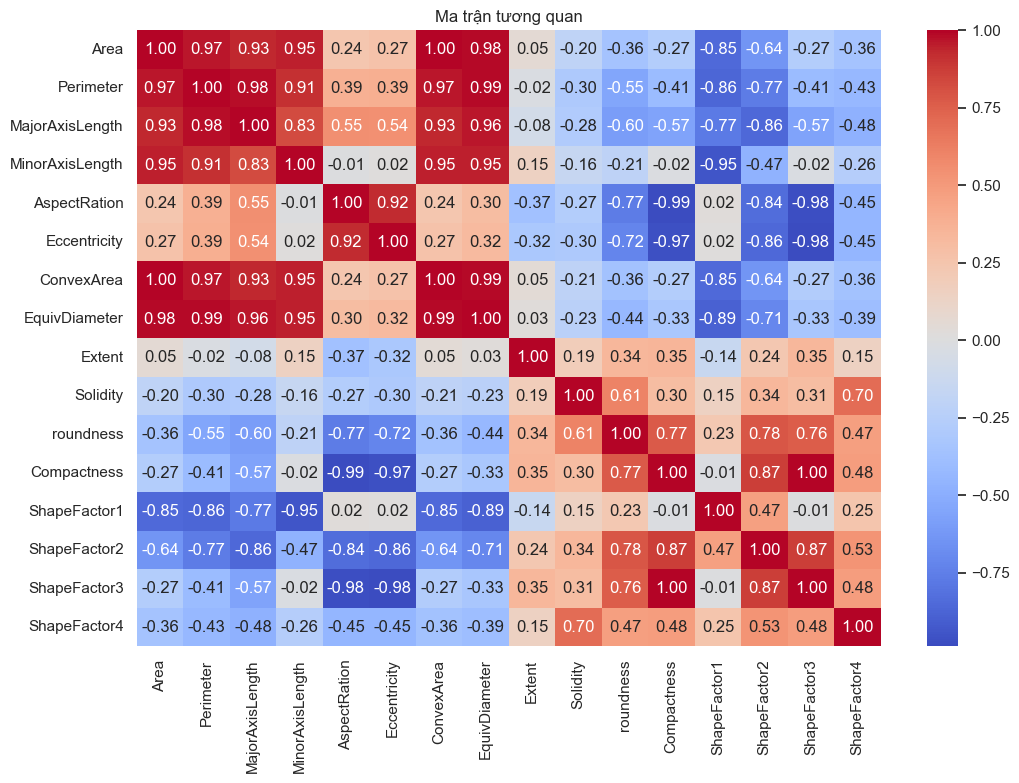

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Ma trận tương quan")
plt.show()

### 4. Phát hiện ngoại lai (outliers) bằng phương pháp IQR hoặc Z-score. 

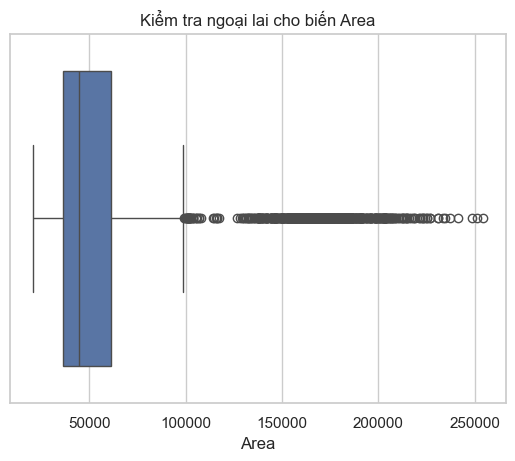

In [7]:
sns.boxplot(x=df['Area'])
plt.title("Kiểm tra ngoại lai cho biến Area")
plt.show()

"Qua ma trận tương quan, nhóm nghiên cứu nhận thấy hiện tượng đa cộng tuyến nghiêm trọng giữa các biến kích thước (Area, Perimeter, Diameter với $r > 0.95$). Để tối ưu hóa mô hình Logistic Regression và đảm bảo tính ổn định của ma trận Hessian khi sử dụng solver Newton-Raphson, chúng tôi quyết định loại bỏ các biến dư thừa và chỉ giữ lại các đại diện tiêu biểu như Area, AspectRation và Solidity."

In [8]:
# Tách dữ liệu thành đặc trưng (X) và mục tiêu (y) TRƯỚC khi lọc đa cộng tuyến
X = df.drop(columns=['Class'])
y = df['Class']

def reduce_multicollinearity(df, threshold=0.95):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    print(f"Các cột bị loại bỏ do đa cộng tuyến (> {threshold}): {to_drop}")
    return df.drop(columns=to_drop)

# Áp dụng lọc trên X
X_reduced = reduce_multicollinearity(X, threshold=0.95)
X = X_reduced # Cập nhật lại X

Các cột bị loại bỏ do đa cộng tuyến (> 0.95): ['Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'ConvexArea', 'EquivDiameter', 'Compactness', 'ShapeFactor3']


In [9]:
# Xử lý Outliers bằng phương pháp Capping (giữ nguyên số lượng dòng)
for col in X.select_dtypes(include=[np.number]).columns:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Thay thế các giá trị vượt ngưỡng bằng giá trị biên
    X[col] = np.where(X[col] < lower_bound, lower_bound, X[col])
    X[col] = np.where(X[col] > upper_bound, upper_bound, X[col])

print("Đã xử lý ngoại lai cho các đặc trưng số.")

Đã xử lý ngoại lai cho các đặc trưng số.


## 3. Tiền xử lý:

### 1. Xử lý giá trị còn thiếu (missing values): nếu có


In [10]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 1. Mã hóa biến mục tiêu y
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 2. Tạo DataFrame đã làm sạch để xuất file CSV (không bao gồm các cột đa cộng tuyến)
df_cleaned = X.copy()
df_cleaned['Class'] = y.values
df_cleaned['Class_Encoded'] = y_encoded
df_cleaned.to_csv('data/dataset.csv', index=False)
print("Đã lưu dữ liệu sạch vào 'data/dataset.csv'")

Đã lưu dữ liệu sạch vào 'data/dataset.csv'


### 2. Chia tập dữ liệu

In [11]:
# 3. Chia tập dữ liệu (Lưu ý: Stratify theo y để cân bằng tỷ lệ các loại đậu)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.125, random_state=42, stratify=y_train_val
)

print(f"Kích thước Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Kích thước Train: (9527, 9), Val: (1361, 9), Test: (2723, 9)


### 3. Chuẩn hóa dữ liệu

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Chỉ fit trên tập Train để tránh Leakage
X_train_scaled = scaler.fit_transform(X_train)

# Transform tập Val và Test dựa trên thông số của tập Train
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Đã chuẩn hóa dữ liệu thành công.")

Đã chuẩn hóa dữ liệu thành công.
